In [1]:
import matplotlib.pyplot as plt
import numpy as np

import freq_statespace as fss

import best_linear_approximation as bla

raw_data = np.load("closed_loop_controller_id.npz")

r = raw_data["r"]
u = raw_data["u"]
e = raw_data["e"]
fs = float(raw_data["fs"])

G_bla = bla.robust.closed_loop(r=r, u=e, y=u, fs=fs)

data = fss.create_data_object_from_bla(G_bla)


print(G_bla.G.total.as_percentage)
print(G_bla.G.noise.as_percentage)


print(G_bla.spectra.Y.total_equation_error.as_percentage)
print(G_bla.spectra.Y.total.as_percentage)
print(G_bla.spectra.Y.noise.as_percentage)

Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).


/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:130: PossibleExcitationAmplitudeMismatchWarning: The relative mismatch between all 9 adjacent channel-realization pairs exceeds the threshold of 2.50%. This may indicate an excitation-amplitude change between realizations. Aggregated relative differences: [11.03%, 11.61%, 6.97%, 8.60%, 10.09%, 10.44%, 11.21%, 10.70%, 10.93%].
  _warn_if_excitation_amplitude_mismatch(r if r is not None else u, max_bin)
/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:132: PossiblePeriodMismatchWarning: The relative spectral mismatch between all 3 adjacent period pairs exceeds the threshold of 2.50%. This may indicate transients, drift, changing excitation, or period-alignment issues. Aggregated relative differences: [59.06%, 53.53%, 54.85%].
  _warn_if_output_spectra_mismatch(y, max_bin)


[[80.06739275]]
[[79.50391012]]
[20.58761948]
[39.4385895]
[35.08365947]


In [4]:
# Step 1: BLA estimation
nx = 1  # state dimension
bla = fss.lin.subspace_id(data, nx)
bla = fss.lin.optimize(bla, data)


=============== Frequency-domain subspace identification ===============
BLA simulation error: 20.02%.

=========================== BLA optimization ===========================
Starting iterative optimization...
    Iter 1 | loss = 3.4390e+00
    Iter 2 | loss = 3.4390e+00
    Iter 3 | loss = 3.4293e+00
    Iter 4 | loss = 3.4289e+00
    Iter 5 | loss = 3.4288e+00
    Iter 6 | loss = 3.4288e+00
    Iter 7 | loss = 3.4288e+00
    Iter 8 | loss = 3.4288e+00
    Iter 9 | loss = 3.4288e+00
    Iter 10 | loss = 3.4288e+00
Optimization completed in 0.03s (10 iterations, 1.28ms/iter).

BLA simulation error: 114.37%.



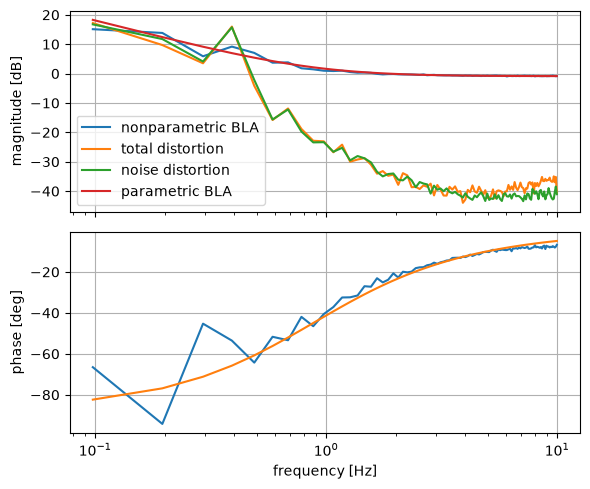

In [16]:
freqs = G_bla.freq.freqs[G_bla.freq.excited_bins]
G_nonparametric = data.freq.G_bla.G[:, 0, 0]
G_total_std = np.sqrt(data.freq.G_bla.var_tot[:, 0, 0])
G_noise_std = np.sqrt(data.freq.G_bla.var_noise[:, 0, 0])
G_parametric = bla._frequency_response(freqs)[:, 0, 0]

fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

axs[0].semilogx(freqs, 20 * np.log10(np.abs(G_nonparametric)), label="nonparametric BLA")
axs[0].semilogx(freqs, 20 * np.log10(np.abs(G_total_std)), label="total distortion")
axs[0].semilogx(freqs, 20 * np.log10(np.abs(G_noise_std)), label="noise distortion")
axs[0].semilogx(freqs, 20 * np.log10(np.abs(G_parametric)), label="parametric BLA")
axs[0].set_ylabel("magnitude [dB]")
axs[0].legend()
axs[0].grid()

axs[1].semilogx(freqs, np.unwrap(np.angle(G_nonparametric)) * 180 / np.pi)
axs[1].semilogx(freqs, np.unwrap(np.angle(G_parametric)) * 180 / np.pi)
axs[1].set_xlabel("frequency [Hz]")
axs[1].set_ylabel("phase [deg]")
axs[1].grid()

plt.tight_layout()
plt.show()

In [14]:
print(bla.D_yu)

[[0.92788035]]


In [3]:
# Step 2: Nonlinear optimization
import jax

neural_net = fss.static.NeuralNetwork(
    nw=1, nz=3, layers=1, neurons_per_layer=64, activation=jax.nn.relu
)
nllfr = fss.nonlin.connect(bla, neural_net)
nllfr = fss.nonlin.optimize(nllfr, data, device="gpu", max_iter=100)

========================= NL-LFR optimization ==========================
Starting iterative optimization...
    BLA loss: 1.0835e-01


KeyboardInterrupt: 

In [ ]:
freqs = G_bla.freq.freqs[G_bla.freq.excited_bins]
G_nonparametric = G_bla.G.value[:, 0, 0]
G_parametric = bla._frequency_response(freqs)[:, 0, 0]

fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

axs[0].semilogx(freqs, 20 * np.log10(np.abs(G_nonparametric)), label="nonparametric BLA")
axs[0].semilogx(freqs, 20 * np.log10(np.abs(G_parametric)), label="parametric BLA")
axs[0].set_ylabel("magnitude [dB]")
axs[0].legend()
axs[0].grid()

axs[1].semilogx(freqs, np.unwrap(np.angle(G_nonparametric)) * 180 / np.pi)
axs[1].semilogx(freqs, np.unwrap(np.angle(G_parametric)) * 180 / np.pi)
axs[1].set_xlabel("frequency [Hz]")
axs[1].set_ylabel("phase [deg]")
axs[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
print(G_bla.spectra.Y.total_equation_error.as_percentage)
print(G_bla.spectra.Y.noise.as_percentage)

[53.31074525 49.15214943 53.87190537]
[4.51404004 4.55642676 4.72775387]
